# Analysis of the F = Cq for CDR claims
Below assumes that you can equate a CDR claim in tCO2e/ha/yr to carbon flux, F, equal to C*q, where q is average water infiltration. Accordingly, you can then bracket what concentrations of DIC or HCO3- alkalinity would be required. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
claim_tCO2_ha_yr = 8.3  # tonnes CO2 per hectare in ~1 year (treated as CO2 for conversion to aqueous C) (derived from validation and verification report: https://puro.earth/documents/content/GmA-e4rASteUvTUJP7GC7Qo2982?download=0; this is a lower-bound -- assuming rock was spread June 21, 2024 and reporting ended June 2, 2025, would give us 8.8 t/ha/yr)
q_mm_yr_grid = np.linspace(50, 1000, 50)  # typical infiltration / recharge bracket (mm/yr)
q_mm_yr_points = np.array([200, 300, 500, 1000])  # for table

# carbonate speciation: choose pH values to show implied TA from a DIC requirement
pH_list = [6.0, 7.0, 8.0]

# constants
M_CO2 = 44.0095   # g/mol
sec_per_yr = 365.25 * 24 * 3600
m2_per_ha = 1e4

# helper conversions
def tCO2_ha_yr_to_molC_m2_s(tCO2_ha_yr):
    """
    Convert t CO2 / ha / yr  -> mol C / m^2 / s
    """
    gCO2_per_ha_yr = tCO2_ha_yr * 1e6
    molCO2_per_ha_yr = gCO2_per_ha_yr / M_CO2
    molC_per_m2_s = molCO2_per_ha_yr / m2_per_ha / sec_per_yr  
    return molC_per_m2_s

def mm_yr_to_m_s(mm_yr):
    return (mm_yr / 1000.0) / sec_per_yr

F_claim = tCO2_ha_yr_to_molC_m2_s(claim_tCO2_ha_yr)
F_claim

5.976235332290535e-07

In [3]:
# compute required concentration C (mol/m^3) for each q
q_m_s = mm_yr_to_m_s(q_mm_yr_grid)
C_req_mol_m3 = F_claim / q_m_s   # F = Cq -> C = F/q

# convert to mM (mmol/L): 1 mol/m^3 = 1 mmol/L = 1 mM
C_req_mM = C_req_mol_m3  # numerically identical

# quick reference table at selected q
q_m_s_pts = mm_yr_to_m_s(q_mm_yr_points)
C_req_pts_mM = F_claim / q_m_s_pts

tbl = pd.DataFrame({
    "q (mm/yr)": q_mm_yr_points,
    "C_required (mM DIC equiv)": C_req_pts_mM
})
tbl

,q (mm/yr),C_required (mM DIC equiv)
0,200,94.297822
1,300,62.865215
2,500,37.719129
3,1000,18.859564


These implied DIC numbers are not realistic for natural systems. Hamilton et al. (2007) for waters draining ag-limed fields in the mid-west report an approximate maximum of ~6 mM ($\text{HCO}_3^-$). DIC values ~>20 mM only occur in $\text{CO}_2$-saturated environments typical of Geological Carbon Storage (GCS) (Kharaka and Hanor, 2004). For example, the max $\text{HCO}_3^-$ observed at the Frio GCS experiment was 50 mM. 

In [4]:
# Back compute ALK at a given pH to see extent to which they could be reporting CO2(aq) as export
# simple carbonate speciation at 25 C (approx; ionic strength effects neglected)
K1 = 10**(-6.35)
K2 = 10**(-10.33)
Kw = 1e-14

def alpha_fractions(H):
    denom = H**2 + K1*H + K1*K2
    a0 = H**2 / denom          # CO2*
    a1 = K1*H / denom          # HCO3-
    a2 = K1*K2 / denom         # CO3--
    return a0, a1, a2

def TA_from_DIC_pH(DIC_mol_L, pH):
    H = 10**(-pH)
    OH = Kw / H
    a0, a1, a2 = alpha_fractions(H)
    HCO3 = a1 * DIC_mol_L
    CO3  = a2 * DIC_mol_L
    TA = HCO3 + 2*CO3 + OH - H  # eq/L (since HCO3 is 1 eq/mol, CO3 is 2 eq/mol)
    return TA

# compute TA (mM eq) implied by required DIC (mM) for several pH
DIC_req_mol_L = (C_req_mM / 1000.0)  # mM -> mol/L
TA_curves_mM = {}
for pH in pH_list:
    TA_curves_mM[pH] = 1000.0 * TA_from_DIC_pH(DIC_req_mol_L, pH)  # mol/L -> mM eq

for pH in pH_list:
    DIC_mol_L_pts = (C_req_pts_mM/1000.0)
    TA_pts_mM = 1000.0 * TA_from_DIC_pH(DIC_mol_L_pts, pH)
    print(f"pH {pH:.1f}: TA @ q={q_mm_yr_points} mm/yr = {np.round(TA_pts_mM, 2)} mM eq")

pH 6.0: TA @ q=[ 200  300  500 1000] mm/yr = [29.12 19.41 11.65  5.82] mM eq
pH 7.0: TA @ q=[ 200  300  500 1000] mm/yr = [77.09 51.39 30.84 15.42] mM eq
pH 8.0: TA @ q=[ 200  300  500 1000] mm/yr = [92.67 61.78 37.07 18.54] mM eq


#### Plot: DIC concentrations (C) versus infiltration (q) required to achieve gross removal flux (F)

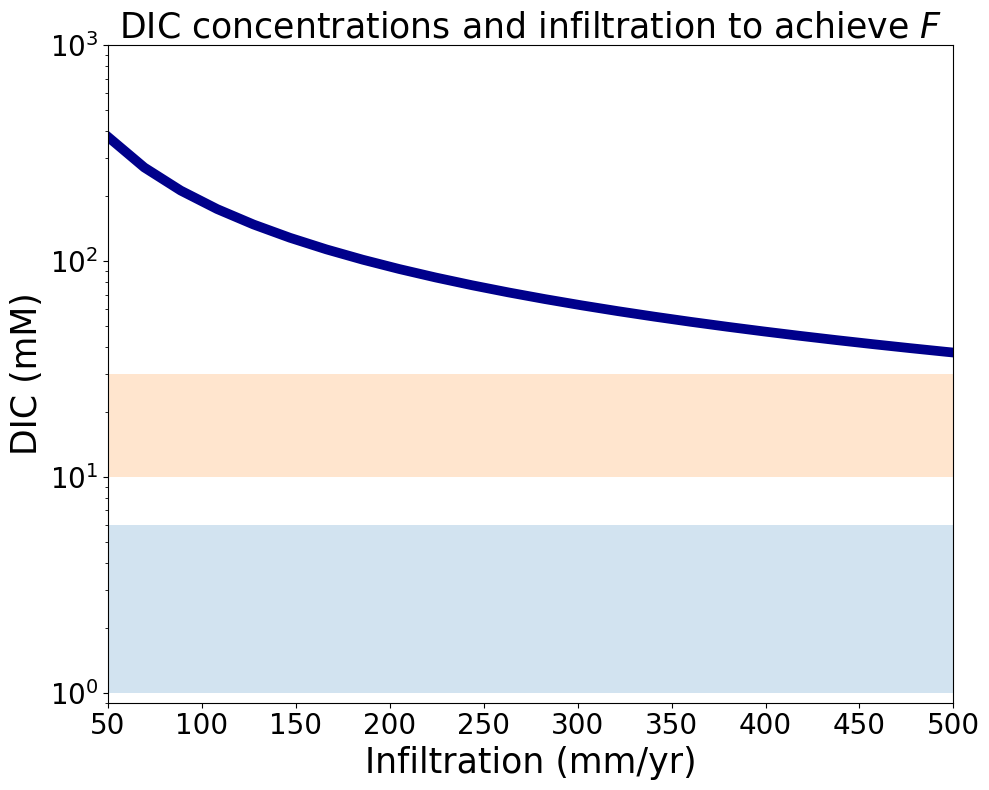

In [9]:
import cmocean as cmo
# -----------------------------------
# [ aesthetics ]
# fonts
fs_lab = 25
fs_tick = 20
fs_leg = 20
# lines
ls = 7
# -----------------------------------

norm = plt.Normalize(min(pH_list), max(pH_list))
cmap = cmo.cm.tempo_r
cmap_start = 0.1   # fraction along the colormap for lowest pH
cmap_end   = 0.85  # fraction along the colormap for highest pH
def scaled_cmap(pH):
    return cmap(cmap_start + (cmap_end - cmap_start) * norm(pH))

plt.figure(figsize=(10,8))
plt.plot(
    q_mm_yr_grid,
    DIC_req_mol_L * 1e3,  # convert mol/L to mM for plotting
    lw=ls,
    color='darkblue',
)

# plausible envelope bands (edit as desired)
# plt.fill_between(q_mm_yr_grid, 1, 6, alpha=0.2, label="'plausible' TA: 1–6 mM eq (Hamilton et al. 2007)" )
plt.fill_between(q_mm_yr_grid, 1, 6, alpha=0.2)    # Hamilton et al. 2007 plausible DIC mM range
plt.fill_between(q_mm_yr_grid, 10, 30, alpha=0.2)  # Kharaka and Hanor, 2004 GCS DIC mM range

plt.yscale("log")
plt.xlabel("Infiltration (mm/yr)", fontsize=fs_lab)
plt.ylabel("DIC (mM)", fontsize=fs_lab)
plt.tick_params(labelsize=fs_tick)
plt.title(r"DIC concentrations and infiltration to achieve $F$", fontsize=fs_lab)
# plt.legend(frameon=False, ncol=2, fontsize=fs_leg)
plt.xlim(50,500)
plt.ylim(0.9e0, 1e3)
plt.grid(False)
plt.tight_layout()
plt.show()

#### Plot: ALK concentrations (C) versus infiltration (q) required to achieve gross removal flux (F) at different pH levels

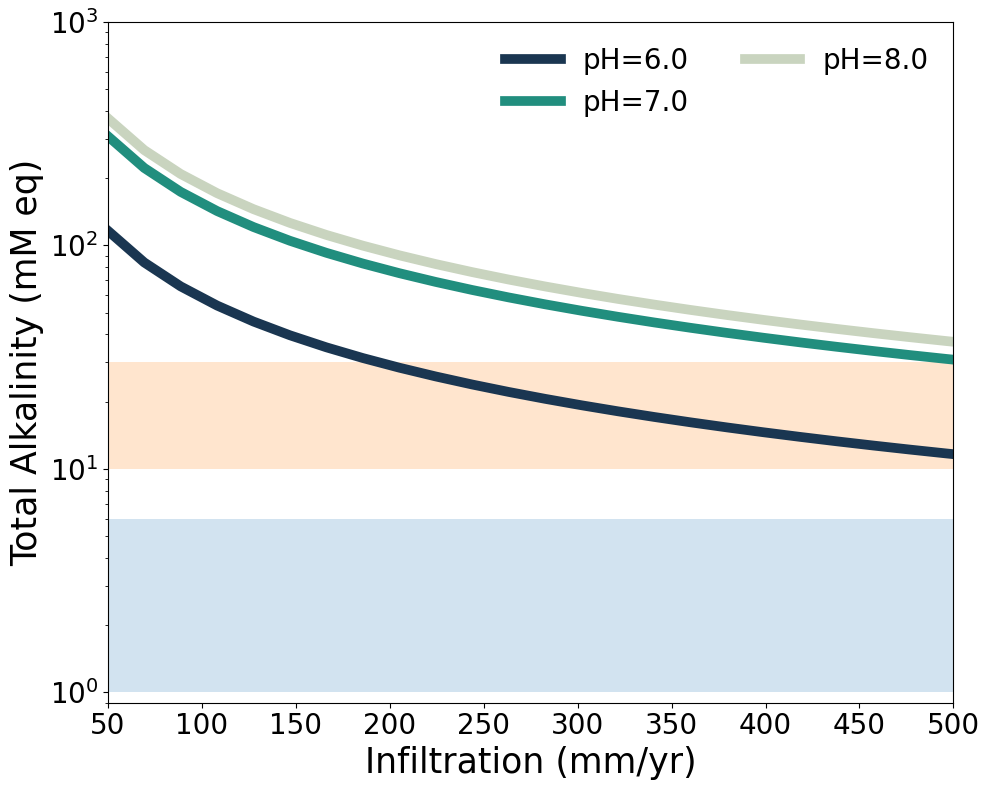

In [11]:
# -----------------------------------
# [ aesthetics ]
# fonts
fs_lab = 25
fs_tick = 20
fs_leg = 20
# lines
ls = 7
# -----------------------------------

norm = plt.Normalize(min(pH_list), max(pH_list))
cmap = cmo.cm.tempo_r
cmap_start = 0.1   # fraction along the colormap for lowest pH
cmap_end   = 0.85  # fraction along the colormap for highest pH
def scaled_cmap(pH):
    return cmap(cmap_start + (cmap_end - cmap_start) * norm(pH))

plt.figure(figsize=(10,8))
for pH in pH_list:
    plt.plot(
        q_mm_yr_grid,
        TA_curves_mM[pH],
        lw=ls,
        label=f"pH={pH:.1f}",
        color=scaled_cmap(pH),
    )

# plausible envelope bands (edit as desired)
# plt.fill_between(q_mm_yr_grid, 1, 6, alpha=0.2, label="'plausible' TA: 1–6 mM eq (Hamilton et al. 2007)" )
plt.fill_between(q_mm_yr_grid, 1, 6, alpha=0.2)
plt.fill_between(q_mm_yr_grid, 10, 30, alpha=0.2)

plt.yscale("log")
plt.xlabel("Infiltration (mm/yr)", fontsize=fs_lab)
plt.ylabel("Total Alkalinity (mM eq)", fontsize=fs_lab)
plt.tick_params(labelsize=fs_tick)
# plt.title("Alkalinity export ")
plt.legend(frameon=False, ncol=2, fontsize=fs_leg)
plt.xlim(50,500)
plt.ylim(0.9e0, 1e3)
plt.grid(False)
plt.tight_layout()
plt.show()

#### Quick visualization: relationship between q and F for various C

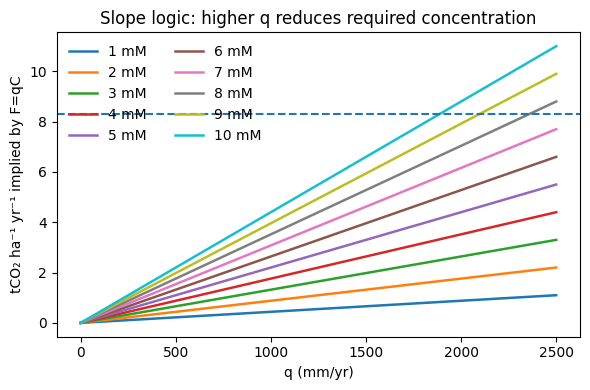

In [13]:
# Plot B: Flux_C vs q for a few assumed concentrations (visualizing 'slope = C')
plt.figure(figsize=(6,4))
q_plot = np.linspace(0, 2500, 200)
q_m_s_plot = mm_yr_to_m_s(q_plot)

# pick illustrative C values (mM)
# Change these to alter the slopes of the limes and intersect with 8
C_list = [1, 2, 3, 4, 5, 6, 7, 8, 9 , 10]  # mM
for C in C_list:
    F = q_m_s_plot * C  # (m/s)*(mol/m^3) = mol/m^2/s; using numeric identity mM=mol/m^3
    # convert back to tCO2/ha/yr
    molC_ha_yr = F * m2_per_ha * sec_per_yr
    tCO2_ha_yr = molC_ha_yr * M_CO2 / 1e6
    plt.plot(q_plot, tCO2_ha_yr, lw=1.8, label=f"{C} mM")

plt.axhline(claim_tCO2_ha_yr, ls="--", lw=1.5) # claimed gross CDR
plt.xlabel("q (mm/yr)")
plt.ylabel("tCO₂ ha⁻¹ yr⁻¹ implied by F=qC")
plt.title("Slope logic: higher q reduces required concentration")
plt.legend(frameon=False, ncol=2)
plt.grid(False)
plt.tight_layout()
plt.show()